**Project 3 - Credit Crad Fraud Detection**

**Identify whether the Transaction is fraud transaction or normal one.**

**1. setup**

In [1]:
# install the required libraries
%pip install -q numpy pandas matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# importing the dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    average_precision_score,
)

In [3]:
# configurations
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
sns.set_theme(style="darkgrid")

RANDOM_STATE = 42

**2. Load Dataset**

In [4]:
df = pd.read_csv("creditcard.csv")

**3. Exploratory Data Analysis(EDA)**

In [5]:
df.shape

(284807, 31)

In [6]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [7]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.000,-1.360,-0.073,2.536,1.378,-0.338,0.462,0.240,0.099,0.364,0.091,-0.552,-0.618,-0.991,-0.311,1.468,-0.470,0.208,0.026,0.404,0.251,-0.018,0.278,-0.110,0.067,0.129,-0.189,0.134,-0.021,149.620,0
1,0.000,1.192,0.266,0.166,0.448,0.060,-0.082,-0.079,0.085,-0.255,-0.167,1.613,1.065,0.489,-0.144,0.636,0.464,-0.115,-0.183,-0.146,-0.069,-0.226,-0.639,0.101,-0.340,0.167,0.126,-0.009,0.015,2.690,0
2,1.000,-1.358,-1.340,1.773,0.380,-0.503,1.800,0.791,0.248,-1.515,0.208,0.625,0.066,0.717,-0.166,2.346,-2.890,1.110,-0.121,-2.262,0.525,0.248,0.772,0.909,-0.689,-0.328,-0.139,-0.055,-0.060,378.660,0
3,1.000,-0.966,-0.185,1.793,-0.863,-0.010,1.247,0.238,0.377,-1.387,-0.055,-0.226,0.178,0.508,-0.288,-0.631,-1.060,-0.684,1.966,-1.233,-0.208,-0.108,0.005,-0.190,-1.176,0.647,-0.222,0.063,0.061,123.500,0
4,2.000,-1.158,0.878,1.549,0.403,-0.407,0.096,0.593,-0.271,0.818,0.753,-0.823,0.538,1.346,-1.120,0.175,-0.451,-0.237,-0.038,0.803,0.409,-0.009,0.798,-0.137,0.141,-0.206,0.502,0.219,0.215,69.990,0


Class:
- 0 -> non-fraud
- 1 -> fraud

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [9]:
# missing values

df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [10]:
# quick check for encoded missing values

for col in df.columns:
    print(df[col].value_counts().head(10))


Time
163152.000    36
64947.000     26
68780.000     25
3767.000      21
3770.000      20
128860.000    19
19912.000     19
140347.000    19
3750.000      19
143083.000    18
Name: count, dtype: int64
V1
1.246    77
2.056    77
2.053    62
1.302    60
2.040    53
2.085    48
1.333    45
1.018    40
1.335    39
1.315    36
Name: count, dtype: int64
V2
0.167     77
-0.327    77
0.090     62
-0.607    60
-0.147    53
0.393     48
0.389     45
1.037     40
0.331     39
-0.034    36
Name: count, dtype: int64
V3
0.488     77
-2.752    77
-1.682    62
-0.682    60
-2.956    53
-4.508    48
-2.166    45
-1.690    40
-2.058    39
-1.090    36
Name: count, dtype: int64
V4
0.635     77
-0.842    77
0.454     62
-1.905    60
-0.578    53
-0.312    48
-0.307    45
1.315     40
-0.346    39
-0.557    36
Name: count, dtype: int64
V5
-0.563    77
2.463     77
0.298     62
1.327     60
2.609     53
3.510     48
2.641     45
1.698     40
2.583     39
2.030     36
Name: count, dtype: int64
V6
-1.011    7

In [11]:
# check duplicates values
duplicate_mask = df.duplicated()
num_duplicates = duplicate_mask.sum()

print("Number of duplicates values:", num_duplicates)

# drop duplicate columns is needed
#df = df.drop_duplicates()


Number of duplicates values: 1081


In [12]:
# Target distribution
print(df["Class"].value_counts())
print(df["Class"].value_counts(normalize=True)*100)

Class
0    284315
1       492
Name: count, dtype: int64
Class
0   99.827
1    0.173
Name: proportion, dtype: float64


**NOTE: Data is Highly Imbalanced**

In [13]:
# imbalace ratio
n_fraud = (df["Class"] == 1).sum()
n_non_fraud = (df["Class"] == 0).sum()
print("\nImbalance ratio (non-fraud : fraud) =", round(n_non_fraud / max(n_fraud, 1), 2))


Imbalance ratio (non-fraud : fraud) = 577.88


Inference: 1 fraud transaction for 557 non-fraud transaction

In [14]:
# descriptive stats for key columns
df[["Time", "Amount"]].describe()

,Time,Amount
count,284807.000,284807.000
mean,94813.860,88.350
std,47488.146,250.120
min,0.000,0.000
25%,54201.500,5.600
50%,84692.000,22.000
75%,139320.500,77.165
max,172792.000,25691.160


**Data visualization**

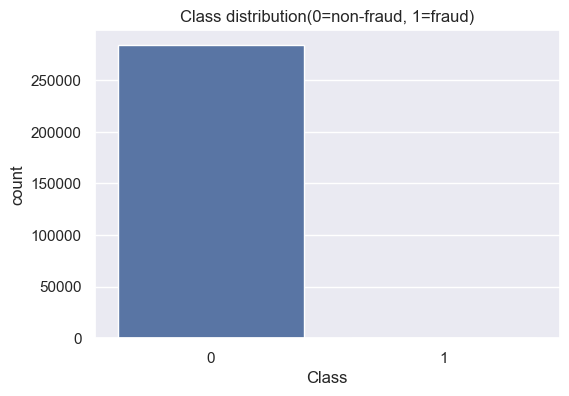

In [15]:
# visualize class imbalance
plt.figure(figsize=(6,4))
sns.countplot(x="Class", data=df)
plt.title("Class distribution(0=non-fraud, 1=fraud)")
plt.show()

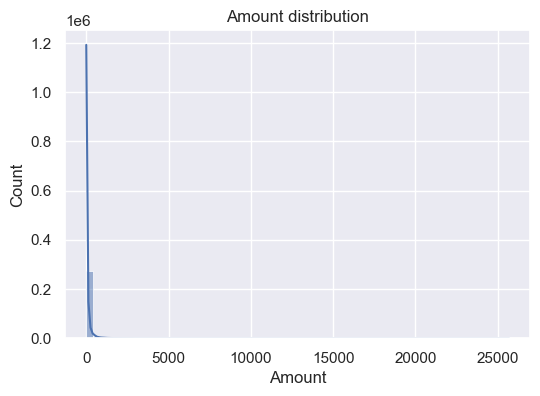

In [16]:
# Amount distribution
plt.figure(figsize=(6,4))
sns.histplot(df["Amount"], bins=60, kde=True)
plt.title("Amount distribution")
plt.show()

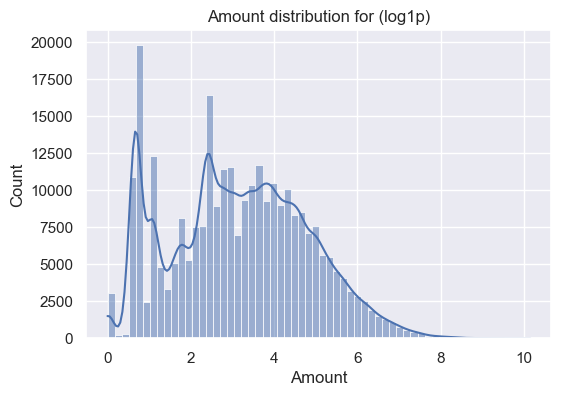

In [17]:
# Amout distribution (raw + loglp)
plt.figure(figsize=(6,4))
sns.histplot(np.log1p(df["Amount"]), bins=60, kde=True)
plt.title("Amount distribution for (log1p)")
plt.show()

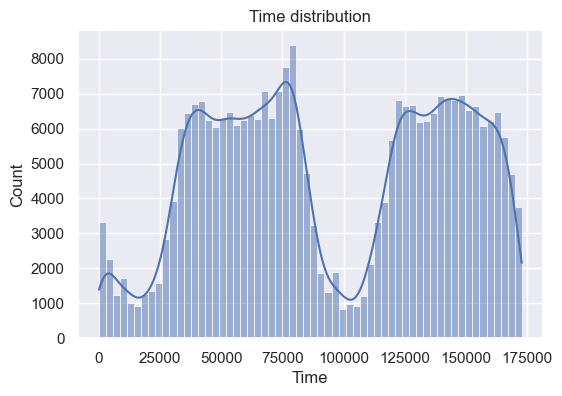

In [18]:
# Time distribution
plt.figure(figsize=(6,4))
sns.histplot(df["Time"], bins=60, kde=True)
plt.title("Time distribution")
plt.show()

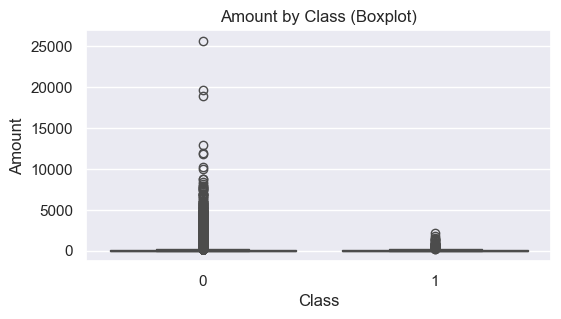

In [19]:
# Amount by class (helps intuition)
plt.figure(figsize=(6, 3))
sns.boxplot(x="Class", y="Amount", data=df)
plt.title("Amount by Class (Boxplot)")
plt.show()

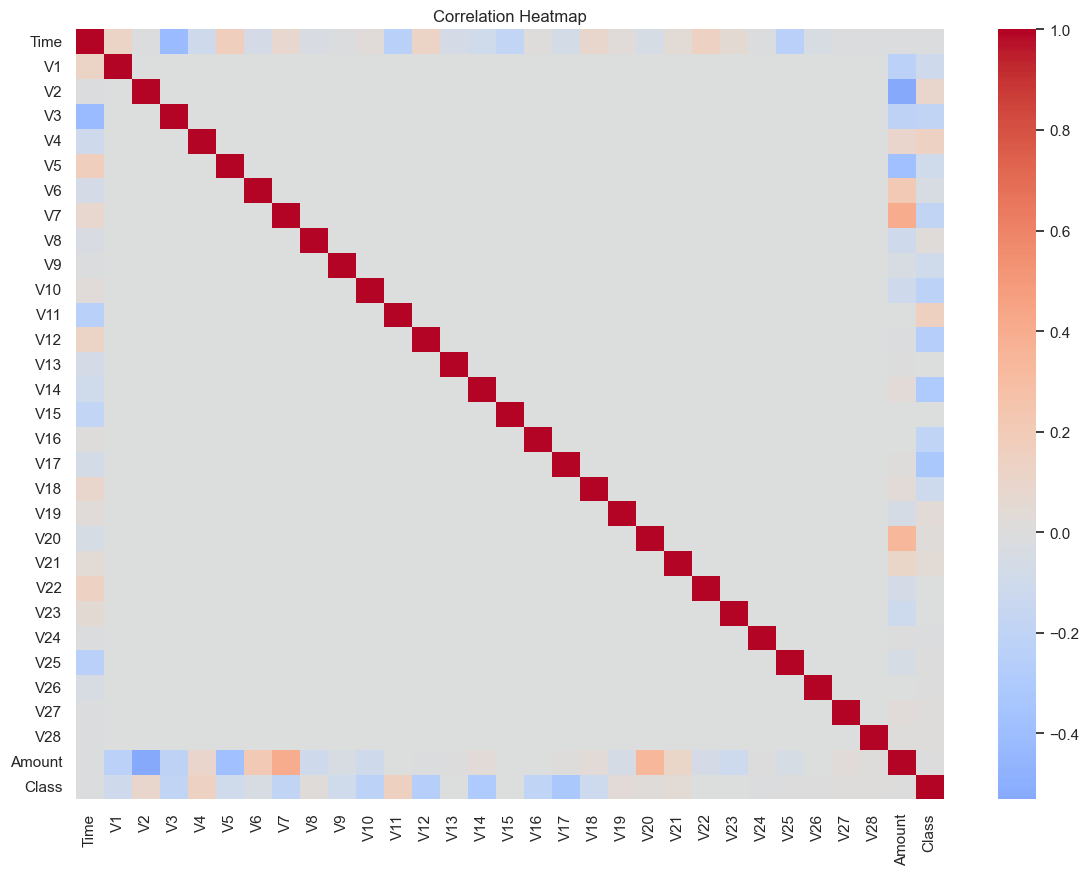

In [20]:
# correlation heatmap (can be heavy but useful)
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

**There are no highly correlated columns (probably beacuase of PCA applied columns)**

In [21]:
# correlation with target (top signals)
corr_target = df.corr(numeric_only=True)["Class"].sort_values(ascending=False)
corr_target.head(5), corr_target.tail(5)

(Class   1.000
 V11     0.155
 V4      0.133
 V2      0.091
 V21     0.040
 Name: Class, dtype: float64,
 V16   -0.197
 V10   -0.217
 V12   -0.261
 V14   -0.303
 V17   -0.326
 Name: Class, dtype: float64)

**4. Data Pre-processing**

In [22]:
# Add log1p(Amount) for stability
df["Amount_log1p"] = np.log1p(df["Amount"])

In [23]:
# Separate features and target
X = df.drop(columns=["Amount", "Class"])
y = df["Class"]

In [24]:
# train test split
X_train, X_test, y_train, y_test = train_test_split( 
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
   )

In [25]:
print("Dataset Shape:", X.shape)
print("Training Data Shape:", X_train.shape)
print("Test Data Shape:", X_test.shape)

Dataset Shape: (284807, 30)
Training Data Shape: (227845, 30)
Test Data Shape: (56962, 30)


**5. Baseline Model**

In [26]:
base_Pipeline = Pipeline(
    [
        ("model", DecisionTreeClassifier(random_state=RANDOM_STATE))
    ]
)

In [27]:
# train the model
base_Pipeline.fit(X_train, y_train)

,steps,"[('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None


In [28]:
y_base_train_pred = base_Pipeline.predict(X_train)
y_base_test_pred = base_Pipeline.predict(X_test)

In [29]:
# get accuracy score
base_train_acc = accuracy_score(y_train, y_base_train_pred)
base_test_acc = accuracy_score(y_test, y_base_test_pred)

In [30]:
print("Training accuracy score:", base_train_acc*100)
print("Test accuracy score:", base_test_acc*100)

Training accuracy score: 100.0
Test accuracy score: 99.91397773954567


In [31]:
# print classification report which will give precision value, recall, f-score and support
print("Classification Report:")
print(classification_report(y_train, y_base_train_pred))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    227451
           1       1.00      1.00      1.00       394

    accuracy                           1.00    227845
   macro avg       1.00      1.00      1.00    227845
weighted avg       1.00      1.00      1.00    227845



In [32]:
print("Classification Report:")
print(classification_report(y_test, y_base_test_pred))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.75      0.74      0.75        98

    accuracy                           1.00     56962
   macro avg       0.88      0.87      0.87     56962
weighted avg       1.00      1.00      1.00     56962



**Note: Accuracy score is not  reliable as class is imbalanced**

In [33]:
# avreage precision score or pr-auc - training data
y_train_prob = base_Pipeline.predict_proba(X_train) [:,1]
print("Training avreage preciion score:", average_precision_score(y_train, y_train_prob))

Training avreage preciion score: 1.0


In [34]:
# avreage precision score or pr-auc - test data
y_test_prob = base_Pipeline.predict_proba(X_test) [:,1]
print("Testing avreage preciion score:", average_precision_score(y_test, y_test_prob))

Testing avreage preciion score: 0.5610321985726947


**6. Model Selection and Optimization**

In [35]:
# perfrom cross validation 
k=5
cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)

In [36]:
models = {
    "dt_balanced":Pipeline(
        [
            ("model", DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced"))
        ]
    ),
    "hgb_balanced": Pipeline(
        [
            ("model", HistGradientBoostingClassifier(random_state=RANDOM_STATE, class_weight="balanced"))
        ]
    ),
    "rfc_balanced":Pipeline(
        [
            ("model", RandomForestClassifier(random_state=RANDOM_STATE, class_weight="balanced"))
        ]
    )
}

In [37]:
for name, m in models.items():
    pr_acc_score =[]

    for tr_idx, te_idx in cv.split(X_train, y_train):
        X_tr, X_te = X_train.iloc[tr_idx], X_train.iloc[te_idx]
        y_tr, y_te = y_train.iloc[tr_idx], y_train.iloc[te_idx]

        m.fit(X_tr, y_tr)
        pred_prob = m.predict_proba(X_te)[:, 1]

        pr_acc_score.append(average_precision_score(y_te, pred_prob))

    print("Model name:", name)
    print("PR-AUC values:", pr_acc_score)
    print("CV PR-AUC mean:", round(float(np.mean(pr_acc_score)), 4))

# cross validation is a more reliable metric

Model name: dt_balanced
PR-AUC values: [0.5007266812564823, 0.4830774702828517, 0.5797304220740939, 0.5880053883273093, 0.5312714890725482]
CV PR-AUC mean: 0.5366
Model name: hgb_balanced
PR-AUC values: [0.7650653511464124, 0.7426863047121038, 0.6961437658687323, 0.7842427747774444, 0.7429545175433017]
CV PR-AUC mean: 0.7462
Model name: rfc_balanced
PR-AUC values: [0.8423466244325414, 0.8148815259132303, 0.830418381185712, 0.8821778726675099, 0.8271070867780583]
CV PR-AUC mean: 0.8394


**Best Model based on model selection process is RandomForest Classifier**

**Hyperparamter Tuning for random forest classifier**

In [38]:
rfc_pipeline = Pipeline(
    [
        ("model", RandomForestClassifier(
            random_state=RANDOM_STATE,
            n_jobs=-1,  #use all the data
            class_weight="balanced_subsample"
        ))
    ]
)

In [39]:
# hyperparamter tuning for random forest classifier
param_dist = {
    "model__n_estimators":[200, 300, 500],
    "model__max_depth":[None, 10, 20, 30],
    "model__min_samples_leaf":[1, 5, 10, 20],
    "model__max_features":["sqrt", "log2", 0.5]
}

In [40]:
# random search
random_search = RandomizedSearchCV(
    estimator=rfc_pipeline,
    param_distributions=param_dist,
    n_iter=10,
    scoring="average_precision",  # PR-AUC
    cv=cv,
    verbose=True
)

In [ ]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


In [ ]:
print("Best CV PR-AUC:", round(random_search.best_score_, 4))
print("Best params:", random_search.best_params_)

Best CV PR-AUC: 0.8433
Best params: {'model__n_estimators': 200, 'model__min_samples_leaf': 1, 'model__max_features': 'log2', 'model__max_depth': 20}


**7. Re-train with best parameters**


In [ ]:
best_rfc = Pipeline(
    [
        ("model", RandomForestClassifier(
            n_estimators=500,
            min_samples_leaf=5,
            max_features="log2",
            max_depth=30,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            class_weight="balanced_subsample"
        ))
    ]
)

In [ ]:
# train best rfc
best_rfc.fit(X_train, y_train)

,steps,"[('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,n_estimators,500
,criterion,'gini'
,max_depth,30
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'log2'


In [ ]:
train_acc = accuracy_score(y_train, y_train_pred)
print(f"Training Accuracy: {round(train_acc*100, 2)} %")

NameError: name 'y_train_pred' is not defined

In [ ]:
# confusion matrix
cm = confusion_matrix(y_train, y_train_pred)

plt.figure(figsize=(4,3))
# heatmap
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred non-fraud", "Pred fraud"],
    yticklabels=["Actual non-fraud", "Actual fraud"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

In [ ]:
print("Training Classification report")
print(classification_report(y_train, y_train_pred))

In [ ]:
train_proba = best_rfc.predict_proba(X_train)[:, 1]
print("Train PR-AUC:", round(average_precision_score(y_train, train_proba), 4))

In [ ]:
# test data prediction
y_test_pred = best_rfc.predict(X_test)

In [ ]:
test_acc = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy: {round(test_acc*100, 2)} %")

In [ ]:
# confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(4,3))
# heatmap
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred non-fraud", "Pred fraud"],
    yticklabels=["Actual non-fraud", "Actual fraud"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

In [ ]:
print("Test Classification report")
print(classification_report(y_test, y_test_pred))

In [ ]:
test_proba = best_rfc.predict_proba(X_test)[:, 1]
print("Test PR-AUC:", round(average_precision_score(y_test, test_proba), 4))

**Build a predictive system**

In [ ]:
def predict_class(input_features):
    input_df = pd.DataFrame(
        [input_features],
        columns=X_train.columns
    )
    # get prediction from trained model
    prediction = best_rfc.predict(input_df)
    print("Model prediction:", prediction)
    if prediction[0] == 1:
        print("Fraud Transaction detected ❌")
    else:
        print("Non-Fraud Transaction ✅")

In [ ]:
X_test.head()

In [ ]:
y_test.head()

In [ ]:
y_test[y_test == 0].head()

In [ ]:
y_test[y_test == 1].head()

In [ ]:
test_1 = X_test.loc[263020].tolist()
print(test_1)

In [ ]:
predict_class(test_1)

In [ ]:
test_2 = X_test.loc[77348].tolist()
print(test_2)

In [ ]:
predict_class(test_2)

In [ ]:
# we can tune probability threshold to improve the performance even more